# Game Sentiment: Predicting Overall Player Sentiment
This project explores the Steam Store Games (Cleaned Dataset) on Kaggle, with the aim of exploring the game features that could elicit greater positive player sentiment.

## 🎯 Objectives
* Clean and prepare dataset to ensure accuracy and usability.
* Perform EDA to explore the relationship between game features and player sentiment.
* Conduct feature engineering to transform raw columns into more useful variables.
* Build and test a XGBoost model to predict overall player sentiment for games based on selected game features.

## Dataset
* Source: [Steam Store Games Dataset] [Steam Store Games (Clean Dataset)](https://www.kaggle.com/datasets/nikdavis/steam-store-games/data)
* Number of Rows: 27075
* Numbner of Columns: 18
* Key Columns: Price, Genre, Categories, Positive_ratings, Negative_ratings, etc

### Load Dataset
We start by loading the Steam Stores Games (Cleaned Dataset) into a Pandas dataframe.

In [40]:
import pandas as pd

# Load dataset
!kaggle datasets download -d nikdavis/steam-store-games

df = pd.read_csv('steam.csv')

df.head()

Dataset URL: https://www.kaggle.com/datasets/nikdavis/steam-store-games
License(s): Attribution 4.0 International (CC BY 4.0)
steam-store-games.zip: Skipping, found more recently modified local copy (use --force to force download)


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


This dataset has 27,075 rows and 18 columns. Each row represents a unique game.

### Inspect the Data
We check the column names, data types, and the number of missing values to better understand ths structure of the dataset.

In [41]:
# Inspect structure of dataset
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

## Data Cleaning
In this section, we prepare the dataset for analysis by:
* Dropping irrelevant or redundant columns
* Splitting chunked text into lists

### Drop Irrelevant/Redundant Columns
We drop the irrelevant or redundant columns that we will not be using in analysis or modelling to clean and simplify the dataset.

In [42]:
# Remove the developer and publisher columns
cols_to_keep = ['name', 'platforms', 'categories','genres', 'steamspy_tags', 'price', 'positive_ratings', 'negative_ratings']
X = df[cols_to_keep].copy()

### Split Chunked Text
Columns containing multiple values (e.g., `categories`, `steamspy_tags` and `platforms`) were split into lists to facilitate further encoding and modelling. This allows each individual tag or category to be treated as a separate feature for machine learning later on.

In [43]:
# Split chunked text into a list
chunk_cols = ['platforms', 'categories', 'steamspy_tags', 'genres']
for col in chunk_cols:
    X[col] = X[col].astype('string')
    X[col] = X[col].str.split(';')

## Exploratory Data Analysis (EDA)
In this section, we explore the dataset by:
* Examining the distribution for numeric features (`price`, `positive ratings` and `negative ratings`)
* Assessing skewness of the price column
* Inspecting the frequencies of categorical features (`platforms`, `categories`, etc)

### Distribution for Numeric Features
We examine the distributions for the numeric features in the dataset to better understand the spread of our dataset.

#### Distribution of Price
We examine the distribution for the `price` column.

In [44]:
X['price'].describe()

count    27075.000000
mean         6.078193
std          7.874922
min          0.000000
25%          1.690000
50%          3.990000
75%          7.190000
max        421.990000
Name: price, dtype: float64

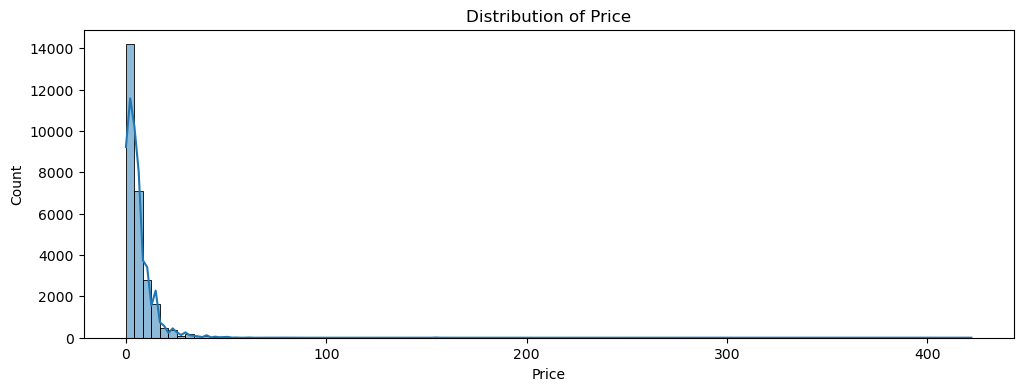

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram for the distribution of price
plt.figure(figsize = (12,4))
sns.histplot(X['price'], bins = 100, kde = True)

plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')

plt.show()

The distribution of price appears to be positively skewed. To better understand the extent of this skewness and decide if transformation is necessary, we proceed to calculate its skewness statistic.

#### Distribution for Positive Ratings
We examine the distribution for the `positive_ratings` column.

In [46]:
X['positive_ratings'].describe()

count    2.707500e+04
mean     1.000559e+03
std      1.898872e+04
min      0.000000e+00
25%      6.000000e+00
50%      2.400000e+01
75%      1.260000e+02
max      2.644404e+06
Name: positive_ratings, dtype: float64

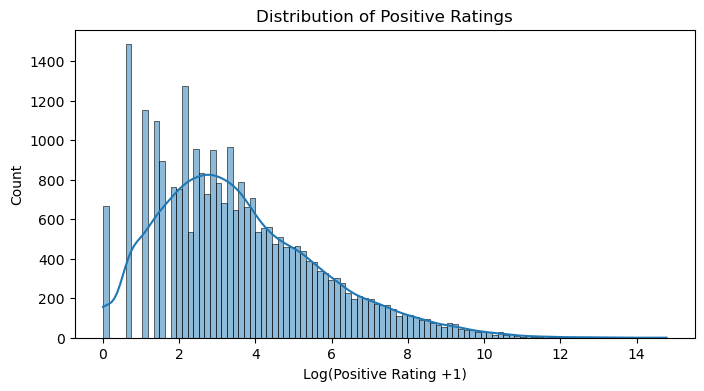

In [47]:
import numpy as np

# Plot histogram for the distribution of positive ratings
plt.figure(figsize = (8,4))
sns.histplot(np.log1p(X['positive_ratings']), bins = 100, kde = True)

plt.title('Distribution of Positive Ratings')
plt.xlabel('Log(Positive Rating +1)')
plt.ylabel('Count')

plt.show()

The distribution of positive ratings appears to be positively skewed. A log transformation was applied to improve visualization. Since a new feature, overall sentiment (our target variable), will be derived from both positive and negative ratings, skewness of positive ratings will not be further investigated.

#### Distribution for Negative Ratings
We examine the distribution for the `negative_ratings` column.

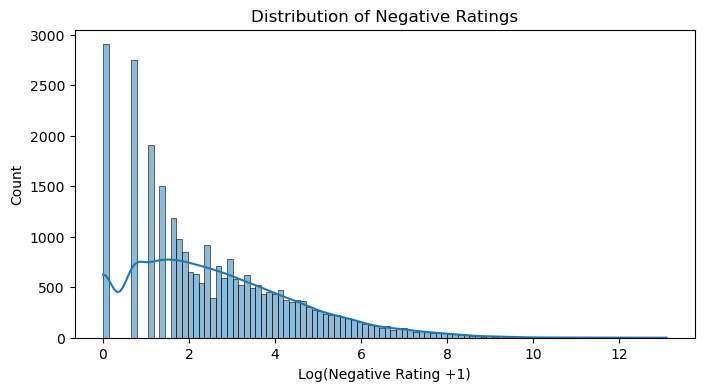

In [48]:
# Plot histogram for the distribution of negative ratings
plt.figure(figsize = (8,4))
sns.histplot(np.log1p(X['negative_ratings']), bins = 100, kde = True)

plt.title('Distribution of Negative Ratings')
plt.xlabel('Log(Negative Rating +1)')
plt.ylabel('Count')

plt.show()

The distribution of negative ratings appears to be somewhat positively skewed. A log transformation was applied to improve visualization. Since a new feature, overall sentiment (our target variable), will be derived from both positive and negative ratings, skewness of negative ratings will not be further investigated.

### Assess Skewness for Price
We calculate the skewness for the `price` column to assess whether the distribution is skewed. If skewness is high, we perform a transformation on the data to reduce skewness.

In [49]:
# Calculate skewness
print(f"Skewness for price: {X['price'].skew()}.")

Skewness for price: 11.732950829962958.


Since the skewness for price is 11.73, it suggests a highly positive skew and we perform a Yeo-Johnson transformation on this column during feature engineering.

### Frequencies for Categorical Features
We inspect the frequency distribution of the categorical features (`genres`, `categories`, `platform` and `steamspy_tags`) to better understand the dataset's composition. This helps us to detect potential imbalances and informs our feature engineering decisions.

#### Frequency Distribution of Genres
We examine the top 10 most common genres in the dataset and plot their frequency distribution to better understand the genre composition of the dataset.

Top 10 Genres:
      Genres  Count
       Indie  19421
      Action  11903
      Casual  10210
   Adventure  10032
    Strategy   5247
  Simulation   5194
         RPG   4311
Early Access   2954
Free to Play   1704
      Sports   1322


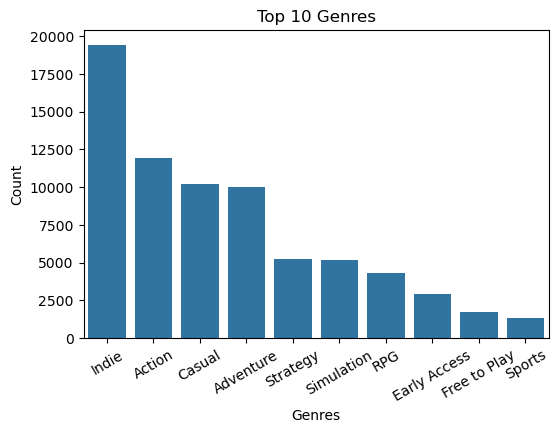

In [50]:
from collections import Counter

# Flatten the entire genres column into a single list containing all individual genre entries
genre_count = Counter([genre for genres in X['genres'] for genre in genres if isinstance(genres, list)])

# Top 10 most common genres in the dataset
genres_df = pd.DataFrame(genre_count.most_common(10), columns = ['Genres', 'Count'])
print(f'Top 10 Genres:\n{genres_df.sort_values('Count', ascending = False).to_string(index = False)}')

# Frequency distribution for the top 10 genres in the dataset
plt.figure(figsize = (6,4))
sns.barplot(x = genres_df['Genres'], y = genres_df['Count'])

plt.xlabel('Genres')
plt.title('Top 10 Genres')
plt.xticks(rotation = 30)

plt.show()

#### Frequency Distribution of Categories
We examine the top 10 most common categories in the dataset and plot their frequency distribution to better understand the category composition of the dataset.

Top 10 Categories:
                Categories  Count
             Single-player  25678
        Steam Achievements  14130
       Steam Trading Cards   7918
               Steam Cloud   7219
   Full controller support   5695
Partial Controller Support   4234
              Multi-player   3974
        Steam Leaderboards   3439
       Online Multi-Player   2487
       Shared/Split Screen   2152


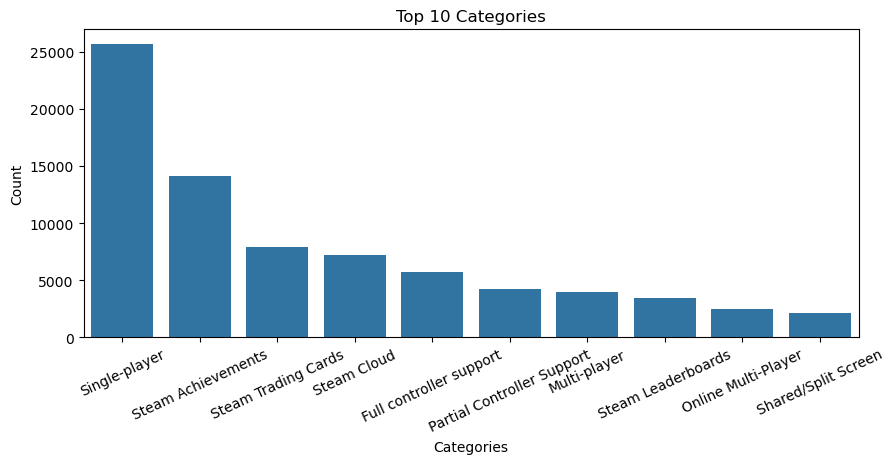

In [51]:
# Flatten the entire categories column into a single list containing all individual category entries
categories_count = Counter([category for categories in X['categories'] for category in categories if isinstance(categories, list)])

# Top 10 most common categories in the dataset
categories_df = pd.DataFrame(categories_count.most_common(10), columns = ['Categories', 'Count'])
print(f'Top 10 Categories:\n{categories_df.sort_values('Count', ascending = False).to_string(index = False)}')

# Frequency distribution for the top 10 categories in the dataset
plt.figure(figsize = (10,4))
sns.barplot(x = categories_df['Categories'], y = categories_df['Count'])

plt.xlabel('Categories')
plt.title('Top 10 Categories')
plt.xticks(rotation = 25)

plt.show()

#### Frequency Distribution of Platforms
We examine the top most common game platforms in the dataset and plot their frequency distribution to better understand the platforms composition of the dataset.

Top Gaming Platforms:
Platforms  Count
  windows  27070
      mac   8066
    linux   5235


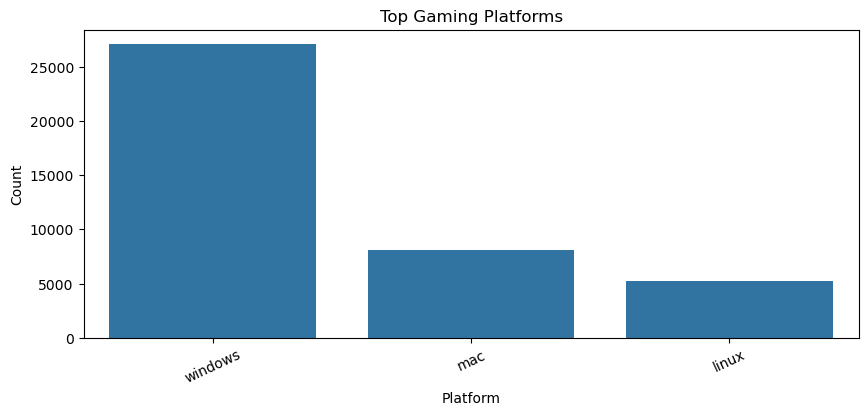

In [52]:
# Flatten the entire platform column into a single list containing all individual platform entries
platforms_count = Counter([platform for platforms in X['platforms'] for platform in platforms if isinstance(platforms, list)])

# Top most common platforms in the dataset
platforms_df = pd.DataFrame(platforms_count.items(), columns = ['Platforms', 'Count'])
print(f'Top Gaming Platforms:\n{platforms_df.sort_values('Count', ascending = False).to_string(index = False)}')

# Frequency distribution for the top platforms in the dataset
plt.figure(figsize = (10,4))
sns.barplot(x = platforms_df['Platforms'], y = platforms_df['Count'])

plt.xlabel('Platform')
plt.title('Top Gaming Platforms')
plt.xticks(rotation = 25)

plt.show()

#### Frequency Distribution of Steamspy_tags
We examine the top 10 most common Steam tags in the dataset and plot their frequency distribution to better understand the tags composition of the dataset.

Top 10 Steam Tags:
        Tags  Count
       Indie  16232
      Action  10322
      Casual   8205
   Adventure   7770
    Strategy   4173
  Simulation   3284
Early Access   2967
         RPG   2785
Free to Play   1662
      Puzzle   1116


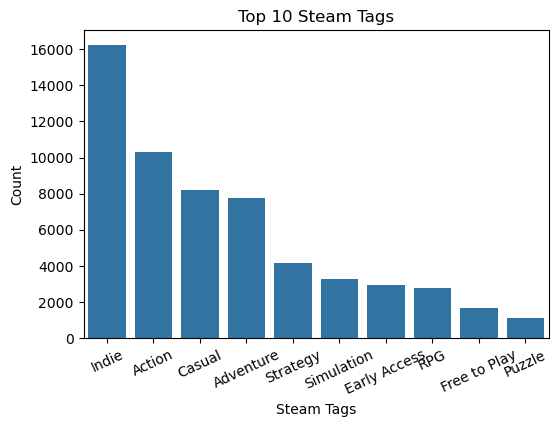

In [53]:
# Flatten the entire steamspy_tags column into a single list containing all individual tag entries
tags_count = Counter([tag for tags in X['steamspy_tags'] for tag in tags if isinstance(tags, list)])

# Top 10 most common steam tags in the dataset
tags_df = pd.DataFrame(tags_count.most_common(10), columns = ['Tags', 'Count'])
print(f'Top 10 Steam Tags:\n{tags_df.sort_values('Count', ascending = False).to_string(index = False)}')

# Frequency distribution for the top 10 steam tags in the dataset
plt.figure(figsize = (6,4))
sns.barplot(x = tags_df['Tags'], y = tags_df['Count'])

plt.xlabel('Steam Tags')
plt.title('Top 10 Steam Tags')
plt.xticks(rotation = 25)

plt.show()

Some overlap exists between the top 10 game genres and Steam tags. To both interpret influential features and predict overall sentiment accurately, both columns will be retained. A tree-based model will be used, with SHAP values to extract feature-level insights while effectively handling redundancy and maintaining prediction accuracy.

## Feature Engineering
In this section, we prepare the dataset for EDA and modelling by:
* Create a new variable - Overall Player Sentiment
* Encoding non-numerical variables (`categories`, `steamspy_tags` and `platforms`)
* Transform numerical values

### Create a New Variable
To facilitate analysis and modelling, we create a new numerical variable called `overall_sentiment` by calculating: **positive_ratings / (positive_ratings + negative_ratings)**. 
This represents the overall player sentiment for each game and provides a single, continuous that can be used directly for analysis and machine-learning modelling.

In [54]:
# Create a new column for overall player sentiment
X_encoded = X[['name']].copy()
X_encoded['overall_sentiment'] = X['positive_ratings']/(X['positive_ratings'] + X['negative_ratings'])

### Encoding the Categorical columns
We conduct multi-label one-hot encoding on the categorical columns (`platforms`, `categories`, `genres` and `steamspy_tags`) so that they can be used for analysis and modelling.

#### Multi-label One-hot Encoding for the `platforms` Feature

In [55]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb_1 = MultiLabelBinarizer()

# Multi-label one-hot encoding
platforms_mlb = mlb_1.fit_transform(X['platforms'])
platforms_dummies = pd.DataFrame(platforms_mlb,
                                columns = mlb_1.classes_,
                                index = X.index)

X_encoded = pd.concat([X_encoded, platforms_dummies], axis = 1)

#### Multi-label One-hot Encoding for the `categories` Feature

In [56]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb_2 = MultiLabelBinarizer()

# Multi-label one-hot encoding
categories_mlb = mlb_2.fit_transform(X['categories'])
categories_dummies = pd.DataFrame(categories_mlb,
                                columns = mlb_2.classes_,
                                index = X.index)

X_encoded = pd.concat([X_encoded, categories_dummies], axis = 1)

#### Multi-label One-hot Encoding for the `steamspy_tags` Feature

In [57]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb_3 = MultiLabelBinarizer()

# Multi-label one-hot encoding
tags_mlb = mlb_3.fit_transform(X['steamspy_tags'])
tags_dummies = pd.DataFrame(tags_mlb,
                                columns = mlb_3.classes_,
                                index = X.index)

X_encoded = pd.concat([X_encoded, tags_dummies], axis = 1)

### Transforming the Skewed Price Column
The data in the price column is highly positively skewed and containes zero values. Since the data represents real world data, a log-transformation is not appropriate (as it is unable to handle zeros meaningfully) - hence, a Yeo-Johnson transformation is applied instead to reduce skewness.

In [58]:
import numpy as np
from scipy.stats import skew, yeojohnson

# Yeo-Johnson Transformation
X_encoded['price_yj'], fitted_lambda = yeojohnson(X['price'])

# Calculate skewness for the transformed price column
print(f'Skewness for transformed price: {skew(X_encoded['price_yj'])}.')

Skewness for transformed price: -0.0024371796295740776.


After applying a yeo-johnson transformation to the price column, skewness was reduced to near 0 - making the distribution more symmetric and better suited for further analysis and modelling.

## Machine Learning
To ensure prediction accuracy, we use a **tree-based XGBoost** model to train and predict overall player sentiment from game features. For interpretability, we calculate SHAP values to identify the features that best influence overall sentiment.

### XGBoost Model

In [69]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score

# --- Preprocessing Data ---
# Extract features and target
x, y = X_encoded.drop(['overall_sentiment', 'name'], axis = 1), X_encoded['overall_sentiment']

# Split the data into test and train data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

# Reset indices
x_train = x_train.reset_index(drop = True)
y_train = y_train.reset_index(drop = True)
x_test = x_test.reset_index(drop = True)
y_test = y_test.reset_index(drop = True)

model = XGBRegressor(random_state = 1)

cv = RepeatedKFold(n_splits = 10, n_repeats = 3, random_state = 1)
# Cross-validation using negative MAE
scores = cross_val_score(model, x_train.values, y_train.values.ravel(), scoring = 'neg_mean_absolute_error', cv = cv, n_jobs = 1)
# Convert negative scores back to positive MAE
print(f'Mean MAE: {round(-1*scores.mean(), 2)} (±{round(scores.std(), 4)})')

Mean MAE: 0.17 (±0.0026)


We first trained an initial baseline XGBoost regression model without any hyperparameter tuning. The baseline model achieved a mean absolute error (MAE) of 0.17 with a standard deviation of ±0.0026, indicating that the model’s performance is both accurate and consistent across cross-validation folds. In the next section, we aim to further improve the model’s performance through hyperparameter tuning to optimize its predictive ability for overall game sentiment.

### Hyperparameter Tuning

In [60]:
from sklearn.model_selection import RandomizedSearchCV

# --- Hyperprameter Tuning with RandomizedSearchCV ---
# --- Round 1: Broad Search ---
parm1 = {
    'learning_rate': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_child_weight': [1, 3 , 5, 7, 9],
    'colsample_bytree': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    'gamma': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    }

# --- Randomized Search ---
random_search_1 = RandomizedSearchCV(model, 
                                     param_distributions = parm1, n_iter = 30, scoring = 'neg_mean_absolute_error', 
                                     n_jobs = 1, cv = cv)

# --- Fit RandomizedSearchCV ---
random_search_1.fit(x_train.values, y_train.values.ravel())

# --- Check the best parameters and score from the round 1 search ---
print(f'Best parameters from search: {random_search_1.best_params_}')
print(f'MAE from search CV: {round(-1*random_search_1.best_score_, 2)}')

# --- Fit a new model using best parameters and check cross-validated score ---
model2 = XGBRegressor(**random_search_1.best_params_, random_state = 1)
cvscores1 = cross_val_score(model2, x_train.values, y_train.values.ravel(), scoring = 'neg_mean_absolute_error', cv = cv)
print(f'MAE value from new model: {round(-1*cvscores1.mean(),2)} (±{round(cvscores1.std(), 4)})')

Best parameters from search: {'n_estimators': 100, 'min_child_weight': 9, 'max_depth': None, 'learning_rate': 0.6, 'gamma': 0.4, 'colsample_bytree': 0.6}
MAE from search CV: 0.17
MAE value from new model: 0.17 (±0.0025)


After performing hyperparameter opimization using RandomizedSearchCV, the model obtained a MAE of 0.17 with a standard deviation of ±0.0028. These results indicate that there was minimal improvement after tuning compared to the baseline model. Therefore, we decide to proceed with the untuned model, as hyperpramater tuning did not lead to any meaningful performance gain.

### Evaluate with Test Data

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fit the original model and evaluate on test data
model.fit(x_train.values, y_train.values.ravel())
y_pred = model.predict(x_test.values)
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE on test data: {round(mae, 2)}')

MAE on test data: 0.16


Evaluating the chosen model on the test data resulted in an MAE of 0.16, which is close to the MAE obtained from training the chosen model. These results suggest that the chosen model, which is our baseline untuned model, is fairly accurate and precise in predicting overall game sentiment. In the next section, we calculate SHAP values to explore which features have the greatest predictive importance.

### SHAP Values

Verification - Model prediction: 0.6528660655021667
Verification - SHAP sum: 0.6528661251068115 (difference: 5.960464477539063e-08)


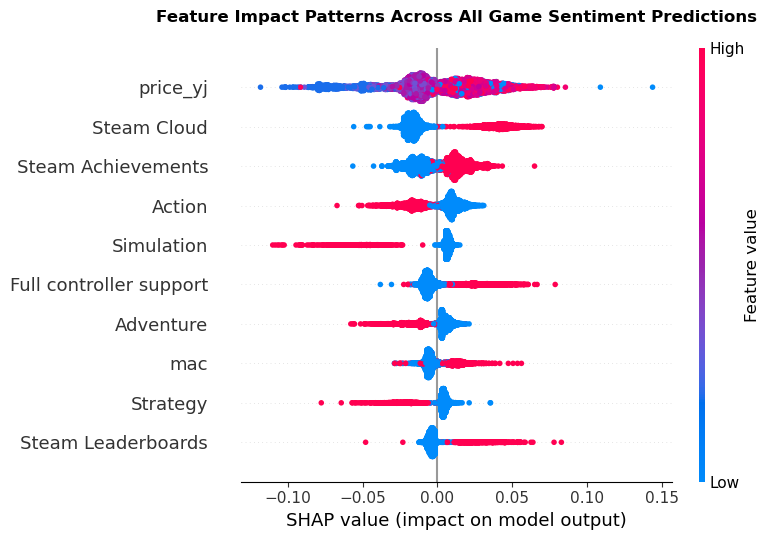


SHAP Ranking		Mean SHAP Value

1 price_yj       	0.025516172870993614
2 Steam Cloud    	0.02361687831580639
3 Steam Achievements	0.013611848466098309
4 Action         	0.013157065957784653
5 Simulation     	0.01220293715596199
6 Full controller support	0.011138794012367725
7 Adventure      	0.008752292953431606
8 mac            	0.007600025739520788
9 Strategy       	0.0073842075653374195
10 Steam Leaderboards	0.007058202289044857


In [125]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP TreeExplainer for our XGBoost model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for our test set
shap_values = explainer.shap_values(x_test.values)

# Verification: SHAP values should be additive
sample_index = 0
model_prediction = model.predict(x_test.values[[sample_index]])[0]
shap_sum = explainer.expected_value + np.sum(shap_values[sample_index])

print(f'Verification - Model prediction: {model_prediction}')
print(f'Verification - SHAP sum: {shap_sum} (difference: {abs(model_prediction - shap_sum)})')

# Summary plot
plt.figure(figsize = (8,4))
shap.summary_plot(
    shap_values,
    x_test,
    max_display = 10,
    show = False
)

plt.title('Feature Impact Patterns Across All Game Sentiment Predictions\n', fontweight = 'bold')
plt.tight_layout()

plt.show()

# SHAP-based importance (mean SHAP values)
shap_importance = np.mean(abs(shap_values), axis = 0)
shap_ranking = pd.DataFrame({
    'Feature': x_test.columns,
    'SHAP_Importance': shap_importance}).sort_values('SHAP_Importance', ascending = False)
print('\nSHAP Ranking\t\tMean SHAP Value\n')

for i in range(10):
    shap_feature = shap_ranking.iloc[i]['Feature']
    shap_value = shap_ranking.iloc[i]['SHAP_Importance']
    print(f'{i+1} {shap_feature:15s}\t{shap_value}')

From the SHAP ranking, the top 5 features with the greatest mean absolute SHAP values are: (1) price, (2) presence of Steam cloud, (3) Steam achievements, (4) action games, and (5) simulation games. The price of a game appears to have the greatest influence over overall game sentiment and therefore, price seems to be the strongest indicator of overall game sentiment.

In addition, from the summary plot:
* Price: The wide spread indicates a strong influence on predictions. Generally, lower-priced games (blue) tend to decrease predicted sentiment while higher-priced games (red) tend to increase it. However, there are some outliers where some lower-prices (blue) still predict higher predicted sentiment, sugessting exceptions based on other features or interactions.
* Steam cloud: Most red predictions (indicating presence of Steam cloud) clustred on the positive side and blue predictions clustred on the negative side - suggesting that having a Steam cloud support tends to increase predicted sentiment.

However, while analysing SHAP values, we observed multiple related multiplayer features appearing separately. This reflects the datset encoding rather than model bias and represents a limiation for this project. In furture revisions, these features could be aggregated to better capture overall feature importance and reduce redundancy.

## Key Insights

### Model Performance
* We trained an XGBoost regression model to predict overall game sentimemnt using a set of key features. The model achieved a mean absolute error (MAE) of 0.16 on test data and a mean MAE of 0.17 during k-folds cross-validation - suggesting that it is both accurate and precise at predicting overall game sentiment.

### Feature Performance
* Based on the SHAP values calculated, **price** and **Steam cloud** had. the greatest influence on prediciting overall game sentiment scores, with a mean absolute SHAP value of 0.0255 and 0.0236, respectively.
* Higher-priced games tend to increase predicted game sentiment, while lower-priced games tend to decrease it.
* Presence of Steam cloud support tends to increase predicted sentiment.
* All other features had mean absolute SHAP values of below 0.02, indicating smaller individual contributions to the model's predictions.

## Next Steps

### Deepen Analysis
* Investigate potential interaction effects to identify how a combination of features may affect overall game sentiment.
* Incorporate game review text in the analysis and apply natural language processing (NLP) to extract insights.
* Use NLP to identify keywords and patterns in player reviews that most influence game sentiment.
* Combing structured features with textual analysis may improve model performance and provide actionable insights for game developers.

### Address Limitations
* Aggregate related features to better capture oerall feature importance and reduce redundancy.

## Conclusion
* Dataset was cleaned, encoded and explored using EDA.
* Build a XGBoost regression model that showed both accurate and precide prediction of overall game sentiment.
* Calculated SHAP values for all the features and identified price as the feature with the strongest influence on game sentiment prediction.